In [7]:
import mne
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Set MNE to be less verbose
mne.set_log_level('WARNING')

In [8]:
# --- Parameters to change ---
epochs_folder = "/Volumes/T9/Circling_dataset/Epochs"
pair_to_load = 2010
subject_to_load = 'a' # 'a' or 'b'

# Define our frequency bands of interest
bands = {
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta': (13.0, 30.0)
}

# Channels of interest for final visualization
channels_to_plot = ['C3', 'C4', 'Oz', 'Fz']
# --- End of parameters ---

# Construct the file path
file_name = f"pair{pair_to_load}_{subject_to_load}-epo.fif"
epochs_file_path = os.path.join(epochs_folder, file_name)

print(f"Loading data from: {epochs_file_path}")

Loading data from: /Volumes/T9/Circling_dataset/Epochs/pair2010_a-epo.fif


In [1]:
import os
import re
import glob
import numpy as np # Optional, used for std dev if available, otherwise built-in math is fine

def parse_rejection_logs(root_folder_path):
    # Regex to find lines like: "Identified 5/118 bad epochs."
    # Group 1 captures bad count, Group 2 captures total count
    pattern = re.compile(r"Identified (\d+)/(\d+) bad epochs")
    
    # Statistics storage
    all_bad_counts = []
    all_total_counts = []
    processed_files = 0
    
    # Recursively find all .md files in the directory structure
    # Matches structure: logs/subject_pair_.../subject_pair_...log.md
    search_path = os.path.join(root_folder_path, "**", "*.md")
    files = glob.glob(search_path, recursive=True)
    
    print(f"Found {len(files)} log files. Parsing...\n")
    
    for file_path in files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                
                # Find all occurrences in the file (usually Subject A and Subject B)
                matches = pattern.findall(content)
                
                if matches:
                    processed_files += 1
                    for bad, total in matches:
                        all_bad_counts.append(int(bad))
                        all_total_counts.append(int(total))
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    # --- Generate Report ---
    if not all_bad_counts:
        print("No rejection data found. Check your folder path.")
        return

    total_bad_epochs = sum(all_bad_counts)
    total_epochs_recorded = sum(all_total_counts)
    total_subjects = len(all_bad_counts) # Each match is one subject (A or B)
    
    # Averages
    avg_bad = total_bad_epochs / total_subjects
    rejection_rate = (total_bad_epochs / total_epochs_recorded) * 100
    
    print("-" * 40)
    print("PREPROCESSING REJECTION REPORT")
    print("-" * 40)
    print(f"Total Log Files Processed:   {processed_files}")
    print(f"Total Subjects Processed:    {total_subjects}")
    print("-" * 40)
    print(f"Total Bad Epochs Removed:    {total_bad_epochs}")
    print(f"Total Epochs Processed:      {total_epochs_recorded}")
    print(f"Global Rejection Rate:       {rejection_rate:.2f}%")
    print("-" * 40)
    print(f"Avg Bad Epochs per Subject:  {avg_bad:.2f} (± {np.std(all_bad_counts):.2f})")
    print("-" * 40)

if __name__ == "__main__":
    # CHANGE THIS to the path of your logs folder
    # If this script is outside the 'logs' folder, use './logs'
    log_directory = "/Volumes/T9/Circling_dataset/Epochs/logs" 
    
    parse_rejection_logs(log_directory)

Found 52 log files. Parsing...

----------------------------------------
PREPROCESSING REJECTION REPORT
----------------------------------------
Total Log Files Processed:   52
Total Subjects Processed:    104
----------------------------------------
Total Bad Epochs Removed:    493
Total Epochs Processed:      12272
Global Rejection Rate:       4.02%
----------------------------------------
Avg Bad Epochs per Subject:  4.74 (± 11.49)
----------------------------------------


In [4]:
import os
import glob
import re
import pandas as pd

def parse_rejection_logs(logs_directory):
    # 1. Find all relevant .md files recursively
    # The pattern matches the file naming convention seen in your screenshot
    search_pattern = os.path.join(logs_directory, "**", "*rejection_log.md")
    files = glob.glob(search_pattern, recursive=True)

    if not files:
        print(f"No files found matching pattern: {search_pattern}")
        return

    data = []

    print(f"Found {len(files)} log files. Parsing...\n")

    for filepath in files:
        with open(filepath, 'r') as f:
            content = f.read()

        # Extract Pair ID from filename (e.g., '2010_03')
        filename = os.path.basename(filepath)
        pair_id_match = re.search(r"pair_(\d+_\d+)", filename)
        pair_id = pair_id_match.group(1) if pair_id_match else "Unknown"

        # --- Extract Subject A Data ---
        # Look for "Epochs A info: 118 epochs"
        total_a_match = re.search(r"Epochs A info:\s*(\d+)\s*epochs", content)
        total_a = int(total_a_match.group(1)) if total_a_match else 0

        # Look for "Identified 0/118 bad epochs" inside the Subject A section
        # We split the file by "Subject B" to ensure we don't grab B's stats for A
        parts = content.split("Running Autoreject for Subject B")
        section_a = parts[0]
        section_b = parts[1] if len(parts) > 1 else ""

        bad_a_match = re.search(r"Identified\s*(\d+)/(\d+)\s*bad epochs", section_a)
        bad_a = int(bad_a_match.group(1)) if bad_a_match else 0
        
        # --- Extract Subject B Data ---
        total_b_match = re.search(r"Epochs B info:\s*(\d+)\s*epochs", content)
        total_b = int(total_b_match.group(1)) if total_b_match else 0

        bad_b_match = re.search(r"Identified\s*(\d+)/(\d+)\s*bad epochs", section_b)
        bad_b = int(bad_b_match.group(1)) if bad_b_match else 0

        # Compile row
        data.append({
            'Pair_ID': pair_id,
            'Total_Epochs_A': total_a,
            'Bad_Epochs_A': bad_a,
            'Good_Epochs_A': total_a - bad_a,
            'Total_Epochs_B': total_b,
            'Bad_Epochs_B': bad_b,
            'Good_Epochs_B': total_b - bad_b,
            'Total_Epochs_Pair': total_a + total_b,
            'Total_Bad_Pair': bad_a + bad_b,
            'Total_Good_Pair': (total_a - bad_a) + (total_b - bad_b)
        })

    # Create DataFrame
    df = pd.DataFrame(data)

    # Calculate Percentages
    df['Rejection_Rate_A (%)'] = (df['Bad_Epochs_A'] / df['Total_Epochs_A']) * 100
    df['Rejection_Rate_B (%)'] = (df['Bad_Epochs_B'] / df['Total_Epochs_B']) * 100
    df['Rejection_Rate_Pair (%)'] = (df['Total_Bad_Pair'] / df['Total_Epochs_Pair']) * 100

    return df

def generate_comprehensive_report(df):

    print("="*60)
    print("PREPROCESSING REJECTION REPORT")
    print("="*60)
    
    # 1. Global Totals
    print(f"\n--- GLOBAL TOTALS (Across {len(df)} Pairs / {len(df)*2} Subjects) ---")
    print(f"Total Epochs Processed:   {df['Total_Epochs_Pair'].sum()}")
    print(f"Total Epochs Removed:     {df['Total_Bad_Pair'].sum()}")
    print(f"Total Epochs Remaining:   {df['Total_Good_Pair'].sum()}")
    global_rej_rate = (df['Total_Bad_Pair'].sum() / df['Total_Epochs_Pair'].sum()) * 100
    print(f"Global Rejection Rate:    {global_rej_rate:.2f}%")

    # 2. Averages
    print(f"\n--- AVERAGE STATISTICS ---")
    print(f"Avg Epochs Removed per Pair:      {df['Total_Bad_Pair'].mean():.2f} (std: {df['Total_Bad_Pair'].std():.2f})")
    print(f"Avg Epochs Removed per Subject:   {(df['Bad_Epochs_A'].mean() + df['Bad_Epochs_B'].mean()) / 2:.2f}")
    print(f"Avg Rejection Rate per Pair:      {df['Rejection_Rate_Pair (%)'].mean():.2f}%")

    # 3. Subject A vs Subject B Comparison
    print(f"\n--- SUBJECT A vs SUBJECT B COMPARISON ---")
    print(f"Total Removed (Subject A): {df['Bad_Epochs_A'].sum()} (Avg: {df['Bad_Epochs_A'].mean():.2f})")
    print(f"Total Removed (Subject B): {df['Bad_Epochs_B'].sum()} (Avg: {df['Bad_Epochs_B'].mean():.2f})")
    
    # 4. Extremes (Outliers)
    print(f"\n--- EXTREMES (Worst/Best Cases) ---")
    worst_pair = df.loc[df['Total_Bad_Pair'].idxmax()]
    best_pair = df.loc[df['Total_Bad_Pair'].idxmin()]
    
    print(f"Highest Rejection Pair: {worst_pair['Pair_ID']} ({int(worst_pair['Total_Bad_Pair'])} bad epochs, {worst_pair['Rejection_Rate_Pair (%)']:.2f}%)")
    print(f"Lowest Rejection Pair:  {best_pair['Pair_ID']} ({int(best_pair['Total_Bad_Pair'])} bad epochs, {best_pair['Rejection_Rate_Pair (%)']:.2f}%)")

    # Optional: Save to CSV
    # df.to_csv("preprocessing_stats_summary.csv", index=False)
    # print("\nDetailed statistics saved to 'preprocessing_stats_summary.csv'")

# --- RUN THE SCRIPT ---
# Replace this path with the actual path to your 'logs' folder
path_to_logs = "/Volumes/T9/Circling_dataset/Epochs/logs" 


# If testing locally with the file structure seen in the image, ensure path is correct
if os.path.exists(path_to_logs):
    df_results = parse_rejection_logs(path_to_logs)
    if df_results is not None:
        generate_comprehensive_report(df_results)
else:
    print("Please set the correct 'path_to_logs' variable in the script.")

Found 52 log files. Parsing...

PREPROCESSING REJECTION REPORT

--- GLOBAL TOTALS (Across 52 Pairs / 104 Subjects) ---
Total Epochs Processed:   12272
Total Epochs Removed:     493
Total Epochs Remaining:   11779
Global Rejection Rate:    4.02%

--- AVERAGE STATISTICS ---
Avg Epochs Removed per Pair:      9.48 (std: 17.10)
Avg Epochs Removed per Subject:   4.74
Avg Rejection Rate per Pair:      4.02%

--- SUBJECT A vs SUBJECT B COMPARISON ---
Total Removed (Subject A): 278 (Avg: 5.35)
Total Removed (Subject B): 215 (Avg: 4.13)

--- EXTREMES (Worst/Best Cases) ---
Highest Rejection Pair: 2310_03 (95 bad epochs, 40.25%)
Lowest Rejection Pair:  2030_03 (0 bad epochs, 0.00%)


In [9]:
try:
    epochs = mne.read_epochs(epochs_file_path, preload=True)
    
    # If metadata doesn't exist (it should from script 02), create it.
    if epochs.metadata is None:
        print("No metadata found, creating new one.")
        epochs.metadata = pd.DataFrame(index=range(len(epochs)))
        
    print("\nSuccessfully loaded epochs:")
    print(epochs)
    print(f"\nNumber of epochs: {len(epochs)}")
    print(f"Sampling frequency: {epochs.info['sfreq']} Hz")
    
except FileNotFoundError:
    print(f"ERROR: File not found at {epochs_file_path}")

# Make a copy of the metadata to work on
metadata = epochs.metadata.copy()


Successfully loaded epochs:
<EpochsFIF | 118 events (all good), 0 – 3.996 s (baseline off), ~63.7 MiB, data loaded, with metadata,
 'closed_baseline_epoch': 59
 'open_baseline_epoch': 59>

Number of epochs: 118
Sampling frequency: 256.0 Hz


In [10]:
print("Calculating power spectral density (PSD) for all epochs...")

# We use mne.compute_psd() which is the modern way.
# We'll calculate for a wide band and then average within our bands of interest.
psd = epochs.compute_psd(method="welch", fmin=1.0, fmax=40.0, picks='eeg')

Calculating power spectral density (PSD) for all epochs...


In [11]:
print("Averaging power within bands and adding to metadata...")

# Loop through each band
for band_name, (fmin, fmax) in bands.items():
    print(f"  Processing {band_name} band ({fmin}-{fmax} Hz)...")
    
    # Get the PSD data for the specific band
    # .get_data() returns a numpy array (n_epochs, n_channels, n_freqs)
    # We then average over the last axis (the frequencies)
    band_power = psd.get_data(fmin=fmin, fmax=fmax).mean(axis=2)
    
    # --- FIX ---
    # We must iterate over psd.ch_names, not epochs.info['ch_names'],
    # because psd only contains the 'eeg' channels we picked.
    
    # Now, add this power to our metadata DataFrame, one column per channel
    for i, ch_name in enumerate(psd.ch_names):
        col_name = f"{band_name}_{ch_name}"
        # This will now correctly loop 64 times (i=0 to 63)
        metadata[col_name] = band_power[:, i]

print("\nRaw power values added to metadata:")
print(metadata.head())

Averaging power within bands and adding to metadata...
  Processing theta band (4.0-8.0 Hz)...
  Processing alpha band (8.0-13.0 Hz)...
  Processing beta band (13.0-30.0 Hz)...

Raw power values added to metadata:
   autoreject_bad     theta_Fp1     theta_AF7     theta_AF3      theta_F1  \
0           False  5.083634e-13  4.521156e-13  8.809602e-13  1.028406e-12   
1           False  9.363800e-13  1.027504e-12  1.126939e-12  1.366617e-12   
2           False  9.206377e-13  1.054649e-12  7.847335e-13  8.503729e-13   
3           False  4.984510e-13  5.768167e-13  3.590590e-13  3.617596e-13   
4           False  8.772700e-13  6.242374e-13  8.671152e-13  1.189771e-12   

       theta_F3      theta_F5      theta_F7     theta_FT7     theta_FC5  ...  \
0  6.520858e-13  5.139197e-13  3.223547e-13  5.124555e-13  5.266165e-13  ...   
1  1.128633e-12  6.496888e-13  8.722966e-13  1.055916e-12  4.504744e-13  ...   
2  7.047932e-13  9.423027e-13  1.018171e-12  6.667828e-13  7.414351e-13  ...   
3  

/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/3449898576.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata[col_name] = band_power[:, i]
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/3449898576.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata[col_name] = band_power[:, i]
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/3449898576.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

In [12]:
print("Normalizing power values (Z-scoring) within subject...")

# Get all the new raw power columns we just created
power_columns = [col for col in metadata.columns if any(col.startswith(band) for band in bands)]

# Create new columns for the z-scored values
for col in power_columns:
    z_col_name = f"z_{col}"
    # Calculate z-score: (value - mean) / std_dev
    # This is done per-channel, per-band, across all epochs for this subject
    metadata[z_col_name] = zscore(metadata[col])
    
print("\nZ-scored power values added:")
print(metadata[[col for col in metadata.columns if col.startswith('z_alpha_')]].head())

Normalizing power values (Z-scoring) within subject...

Z-scored power values added:
   z_alpha_Fp1  z_alpha_AF7  z_alpha_AF3  z_alpha_F1  z_alpha_F3  z_alpha_F5  \
0    -1.568224    -1.762146    -0.286511   -0.036226   -0.565117   -0.965476   
1    -0.088799     0.170840    -0.489394   -0.712377   -0.653554   -0.787422   
2     0.035770    -0.396645     0.248944   -0.268254   -0.160814    0.579876   
3    -1.375125    -1.375198    -1.503049   -0.644800   -1.030045   -1.367789   
4    -0.815143    -0.377552    -0.081781   -0.063579    0.013733   -0.782035   

   z_alpha_F7  z_alpha_FT7  z_alpha_FC5  z_alpha_FC3  ...  z_alpha_CP4  \
0   -1.427856    -0.350676    -0.750390    -0.163231  ...    -0.970796   
1   -0.166095     0.067554    -0.830659    -0.518646  ...    -0.653527   
2   -0.390555    -0.291024    -0.890551    -0.711399  ...    -1.560147   
3   -1.348472    -0.958772    -1.303179    -0.206799  ...    -0.941982   
4   -1.454478    -0.302439    -0.845680    -0.106157  ...    -0.

/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/2154423363.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata[z_col_name] = zscore(metadata[col])
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/2154423363.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata[z_col_name] = zscore(metadata[col])
/var/folders/h6/wwzpvb4141g4m6j_2c1k19gr0000gp/T/ipykernel_28962/2154423363.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inser

Plotting histograms of normalized (Z-scored) power...


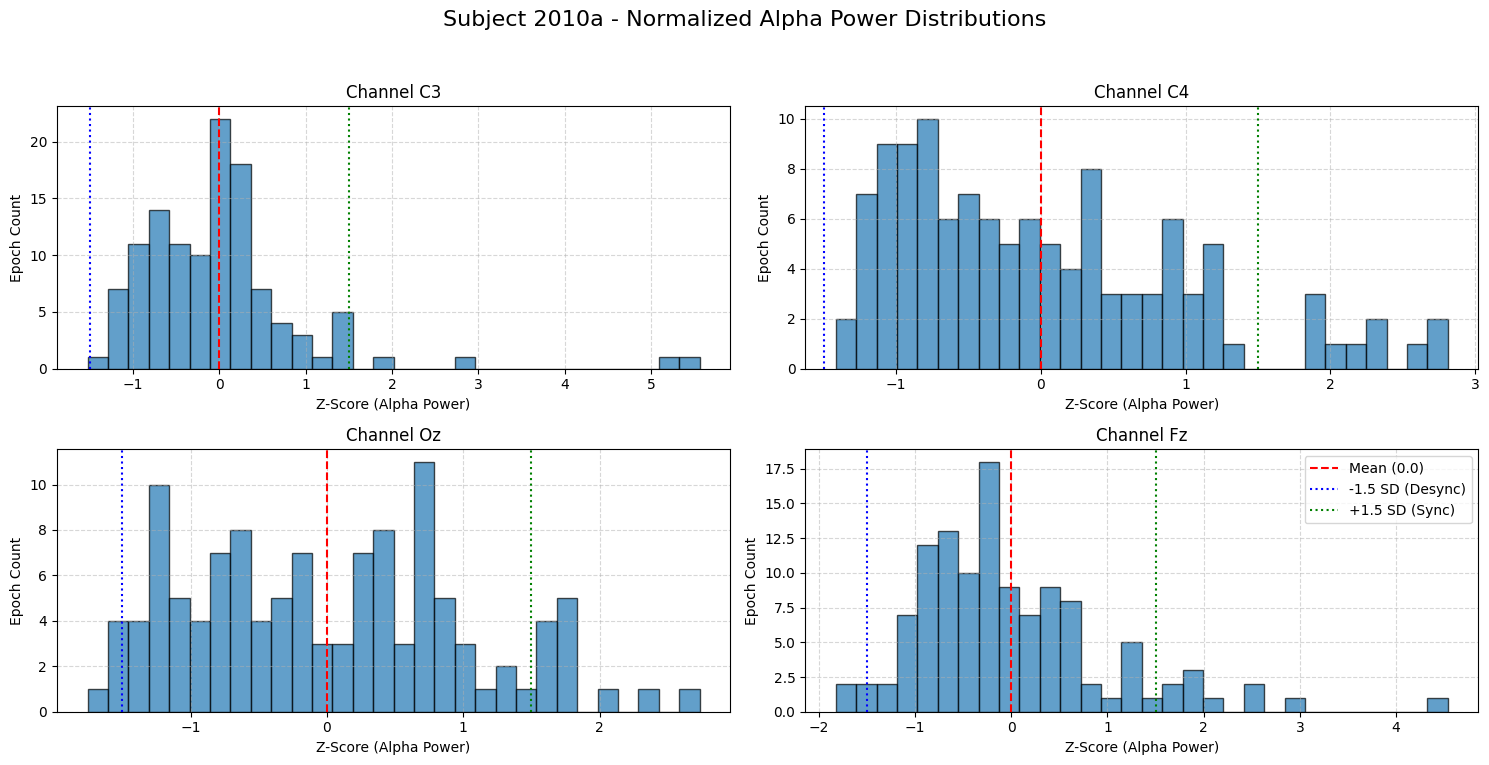

In [13]:
print("Plotting histograms of normalized (Z-scored) power...")

# Let's look at the alpha band for our channels_to_plot
plt.figure(figsize=(15, 8))
plt.suptitle(f"Subject {pair_to_load}{subject_to_load} - Normalized Alpha Power Distributions", fontsize=16)

n_channels = len(channels_to_plot)

for i, ch_name in enumerate(channels_to_plot):
    plt.subplot(2, (n_channels + 1) // 2, i + 1)
    
    z_col_name = f"z_alpha_{ch_name}"
    
    if z_col_name in metadata.columns:
        data = metadata[z_col_name]
        plt.hist(data, bins=30, alpha=0.7, edgecolor='black')
        plt.title(f"Channel {ch_name}")
        plt.xlabel("Z-Score (Alpha Power)")
        plt.ylabel("Epoch Count")
        plt.axvline(0, color='red', linestyle='--', label='Mean (0.0)')
        plt.axvline(-1.5, color='blue', linestyle=':', label='-1.5 SD (Desync)')
        plt.axvline(1.5, color='green', linestyle=':', label='+1.5 SD (Sync)')
        plt.grid(True, linestyle='--', alpha=0.5)
        
    else:
        plt.title(f"Channel {ch_name} (Not Found)")

plt.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
print("Demonstrating how to sample epochs to create a 'concept'...\n")

# --- Concept: Alpha Desynchronization at C3 ---
# We define this as epochs where the z-scored alpha power is very low
desync_threshold = -1.5
desync_col = 'z_alpha_C3'

# Use the metadata to create a boolean mask
low_alpha_mask = metadata[desync_col] < desync_threshold

# Select the epoch indices
low_alpha_indices = metadata[low_alpha_mask].index
print(f"Found {len(low_alpha_indices)} epochs for 'Low Alpha @ C3' concept (Z < {desync_threshold})")

# --- Concept: Alpha Synchronization at C3 ---
# We define this as epochs where the z-scored alpha power is very high
sync_threshold = 1.5
sync_col = 'z_alpha_C3'

high_alpha_mask = metadata[sync_col] > sync_threshold
high_alpha_indices = metadata[high_alpha_mask].index
print(f"Found {len(high_alpha_indices)} epochs for 'High Alpha @ C3' concept (Z > {sync_threshold})")

# --- Concept: "Random" or "Neutral" ---
# We can define this as epochs near the mean
neutral_mask = metadata[sync_col].between(-0.5, 0.5)
neutral_indices = metadata[neutral_mask].index
print(f"Found {len(neutral_indices)} epochs for 'Neutral Alpha @ C3' concept (-0.5 < Z < 0.5)")

Demonstrating how to sample epochs to create a 'concept'...

Found 1 epochs for 'Low Alpha @ C3' concept (Z < -1.5)
Found 5 epochs for 'High Alpha @ C3' concept (Z > 1.5)
Found 60 epochs for 'Neutral Alpha @ C3' concept (-0.5 < Z < 0.5)


In [15]:
STANDARD_CHANNELS = [
    'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8',
    'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8',
    'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8',
    'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8',
    'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8',
    'P9', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'P10',
    'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz'
]

len(STANDARD_CHANNELS)

64